# Correlation

**Correlation** measures the relationship between numerical variables.

### Visual working definition

We will start with a graphical description of what *correlation* is.

Graphically, **it measures how clustered the scatter diagram is around a straight line**.

Figure 7.10 shows eight plots and their corresponding correlations.

- Only when the relationship is perfectly linear is the correlation either -1 or +1.
- If the relationship is strong and positive, the correlation will be near +1.
- If it is strong and negative, it will be near -1.
- If there is no apparent linear relationship between the variables, then the correlation will be near zero.

![](../../assets/correlation_coefficient.png)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_theme(style="darkgrid")

path_data = '../../data/'

## Example: Hybrid Cars Dataset

The table `hybrid` contains data on hybrid passenger cars sold in the United States from 1997 to 2013. The data were adapted from the online data archive of [Prof. Larry Winner](http://www.stat.ufl.edu/%7Ewinner/) of the University of Florida. The columns:

- `vehicle`: model of the car
- `year`: year of manufacture
- `msrp`: manufacturer's suggested retail price in 2013 dollars
- `acceleration`: acceleration rate in km per hour per second
- `mpg`: fuel econonmy in miles per gallon
- `class`: the model's class.

In [12]:
hybrid = pd.read_csv(path_data + 'hybrid.csv')

In [13]:
hybrid

,vehicle,year,msrp,acceleration,mpg,class
0,Prius (1st Gen),1997,24509.74,7.46,41.26,Compact
1,Tino,2000,35354.97,8.20,54.10,Compact
2,Prius (2nd Gen),2000,26832.25,7.97,45.23,Compact
3,Insight,2000,18936.41,9.52,53.00,Two Seater
4,Civic (1st Gen),2001,25833.38,7.04,47.04,Compact
...,...,...,...,...,...,...
148,S400,2013,92350.00,13.89,21.00,Large
149,Prius Plug-in,2013,32000.00,9.17,50.00,Midsize
150,C-Max Energi Plug-in,2013,32950.00,11.76,43.00,Midsize
151,Fusion Energi Plug-in,2013,38700.00,11.76,43.00,Midsize


### Relationship 1: Price vs. Acceleration

The graph below is a **scatter plot** of `msrp` *versus* `acceleration`. That means:

- `msrp` is plotted on the vertical axis
- `accelaration` on the horizontal

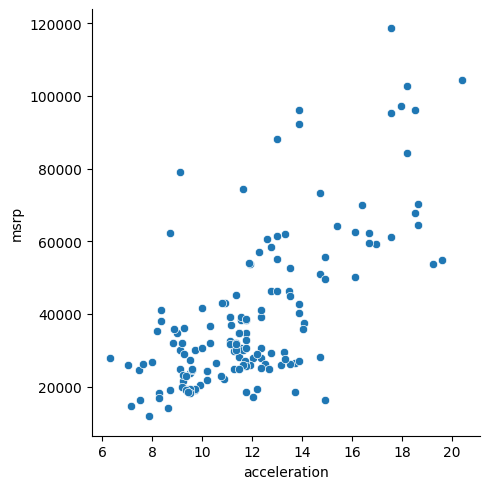

In [14]:
g = sns.relplot(
    data=hybrid, x='acceleration', y='msrp',
    kind='scatter',
    height=5,
)

**Notice the positive association**. The scatter of points is **sloping upwards**, indicating that cars with greater acceleration tended to cost more, on average; conversely, the cars that cost more tended to have greater acceleration on average. 

### Relationship 2: Price vs Efficiency

The scatter diagram of MSRP versus mileage shows **a negative association**. Hybrid cars with higher mileage tended to cost less, on average. This seems surprising till you consider that **cars that accelerate fast tend to be less fuel efficient and have lower mileage**. As the previous scatter plot showed, those were also the cars that tended to cost more. 

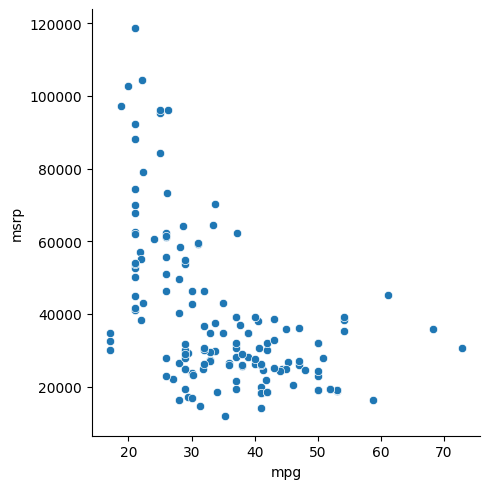

In [15]:
g = sns.relplot(
    data=hybrid, x='mpg', y='msrp',
    kind='scatter',
    height=5,
)

Along with the negative association, the scatter diagram of price versus efficiency shows a non-linear relation between the two variables. The points appear to be clustered around a curve, **not around a straight line**. 

### Relationship 3: Price vs Efficiency (SUV)

**If we restrict the data just to the SUV class**, however, the association between price and efficiency is still **negative but the relation appears to be more linear**.

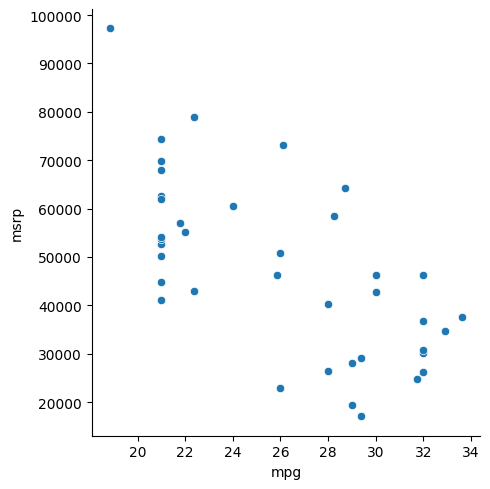

In [16]:
suv = hybrid[hybrid['class'] == 'SUV'].copy()
g = sns.relplot(
    data=suv, x='mpg', y='msrp',
    kind='scatter',
    height=5,
)

### Relationship 4: Price vs Acceleration (SUV)

The relation between the price and acceleration of SUV's also shows a **linear trend, but with a positive slope**.

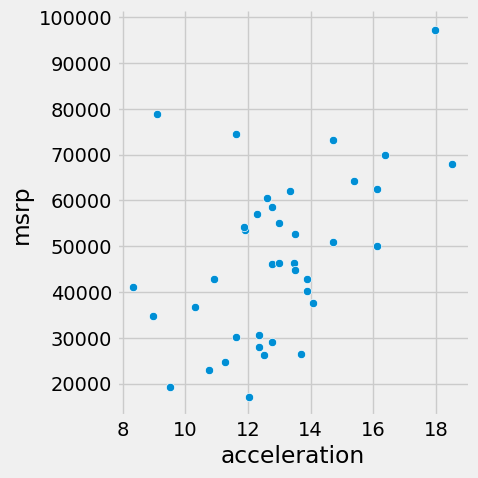

In [69]:
g = sns.relplot(
    data=suv, x='acceleration', y='msrp',
    kind='scatter',
    height=5,
);

## The correlation coefficient

**Correlation** (a.k.a *Pearson correlation coefficient* or linear association) which always takes values between `-1` and `1`, describes the **strength and direction** of the linear relationship between two variables. We denote the correlation by $r$.

### Definition: Math

The formula for correlation is:

$$
r = \frac{1}{n-1} \sum_{i=1}^{n} \left( \frac{x_i-\bar{x}}{s_x} \right) \left( \frac{y_i-\bar{y}}{s_y} \right)
$$

The terms inside the parentheses are exactly the definitions of $z$-scores for $x$ and $y$:

- $z_{x,i} = \frac{x_i-\bar{x}}{s_x}$
- $z_{y,i} = \frac{y_i-\bar{y}}{s_y}$

So, the formula simplifies to:

$$
r = \frac{\sum z_x z_y}{n-1}
$$

In essence, **correlation $r$ is the average of the products of the two variables, when both variables are measured in standard units.**

### Definition: Code

Hence we can define $r$ in two Python functions as follows:


In [ ]:
def standard_units(nums: np.ndarray) -> np.ndarray:
    z = (nums - np.mean(nums))/np.std(nums)
    return z

In [ ]:
def correlation(df: pd.DataFrame, x: str, y: str) -> float:
    z_x = standard_units(df[x])
    z_y = standard_units(df[y])
    return np.mean(z_x * z_y)

## Calculation breakdown

Here are the steps in the calculation. We will apply the steps to a simple table of values of $x$ and $y$.

In [80]:
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6],
    'y': [1, 2, 3, 4, 4, 6],
})
df

,x,y
0,1,1
1,2,2
2,3,3
3,4,4
4,5,4
5,6,6


Based on the scatter diagram, we expect that $r$ will be positive but not equal to 1.

(0.0, 7.0)

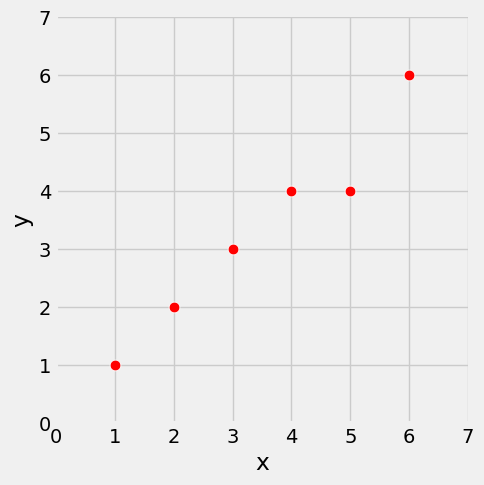

In [90]:
g = sns.relplot(
    data=df,
    x='x', y='y',
    kind='scatter',
    s=60, color='red',
    height=5,
)
g.ax.set_xlim(0, 7)
g.ax.set_ylim(0, 7)

**Step 1.** Convert each variable to standard units.

In [94]:
df_su = df.copy()
df_su['x (standard units)'] = standard_units(df['x'])
df_su['y (standard units)'] = standard_units(df['y'])
df_su

,x,y,x (standard units),y (standard units)
0,1,1,-1.46385,-1.459601
1,2,2,-0.87831,-0.834058
2,3,3,-0.29277,-0.208514
3,4,4,0.29277,0.417029
4,5,4,0.87831,0.417029
5,6,6,1.46385,1.668115


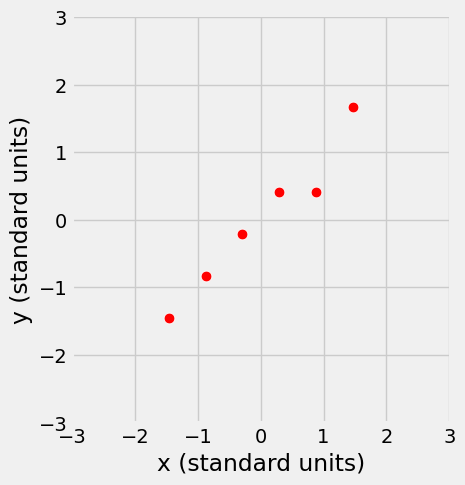

In [95]:
g = sns.relplot(
    data=df_su,
    x='x (standard units)', y='y (standard units)',
    kind='scatter',
    s=60, color='red',
    height=5,
)
g.ax.set_xlim(-3, 3)
g.ax.set_ylim(-3, 3);

**Step 2.** Multiply each pair of standard units.

In [96]:
df_su['product of standard units'] = df_su['x (standard units)'] * df_su['y (standard units)']
t_product = df_su
t_product

,x,y,x (standard units),y (standard units),product of standard units
0,1,1,-1.46385,-1.459601,2.136637
1,2,2,-0.87831,-0.834058,0.732561
2,3,3,-0.29277,-0.208514,0.061047
3,4,4,0.29277,0.417029,0.122094
4,5,4,0.87831,0.417029,0.366281
5,6,6,1.46385,1.668115,2.441871


**Step 3.** $r$ is the average of the products computed in Step 2.

In [104]:
r = df_su['product of standard units'].mean()
print(r.round(3))

0.977


As expected, **$r$ is positive** but not equal to 1.

We could've also just used our own function `correlation` like so:

In [125]:
r = correlation(df, 'x', 'y')
print(r.round(3))

0.977


Practically, we would use one from a library such as `scipy.stats` like so:

In [130]:
from scipy import stats

result = stats.pearsonr(df['x'], df['y'])
result

PearsonRResult(statistic=np.float64(0.9767483130677754), pvalue=np.float64(0.0008046760107910757))

The `statistic` attribute is the correlation coefficient $r$ we're looking for.

In [133]:
print(result.statistic.round(3))

0.977


## Playground: copy-modify-run

**Try**: call the function below with different values of `r` to generate data that fits that correlation coefficient.

In [ ]:
import numpy as np
import seaborn as sns

# Source: https://inferentialthinking.com/chapters/15/1/correlation/
def r_scatter(r):
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    g = sns.relplot(x=x, y=y, kind='scatter', height=5)
    g.ax.set_xlim(-4, 4)
    g.ax.set_ylim(-4, 4)

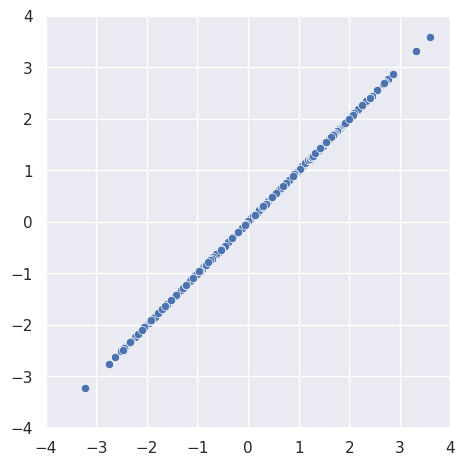

In [14]:
r_scatter(1) # CHANGE THIS LINE TO SEE DIFFERENT CORRELATIONS

## Application on the Hybrid Cars Dataset

In [138]:
from scipy import stats

rel1_corr, _ = stats.pearsonr(hybrid['acceleration'], hybrid['msrp'])
rel2_corr, _ = stats.pearsonr(hybrid['mpg'], hybrid['msrp'])
rel3_corr, _ = stats.pearsonr(suv['mpg'], suv['msrp'])
rel4_corr, _ = stats.pearsonr(suv['acceleration'], suv['msrp'])

Let's lay down all the plots from above, and show their correlation as text on the plot:

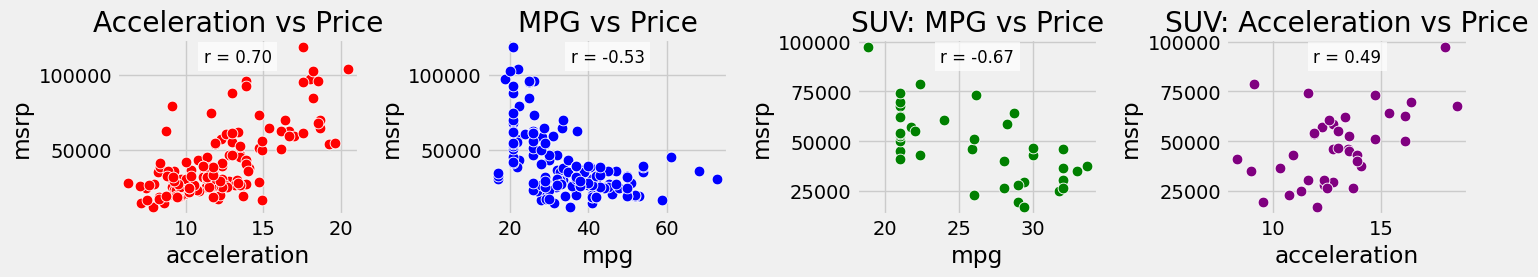

In [139]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 3))


# Relationship 1: Price vs. Acceleration (Hybrid)
sns.scatterplot(x='acceleration', y='msrp', data=hybrid, s=60, color='red', ax=ax[0])
ax[0].set_title('Acceleration vs Price')
ax[0].text(0.5, 0.9, f'r = {rel1_corr:.2f}', ha='center', va='center', 
           transform=ax[0].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 2: Price vs Efficiency (Hybrid)
sns.scatterplot(x='mpg', y='msrp', data=hybrid, s=60, color='blue', ax=ax[1])
ax[1].set_title('MPG vs Price')
ax[1].text(0.5, 0.9, f'r = {rel2_corr:.2f}', ha='center', va='center', 
           transform=ax[1].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 3: Price vs Efficiency (SUV)
sns.scatterplot(x='mpg', y='msrp', data=suv, s=60, color='green', ax=ax[2])
ax[2].set_title('SUV: MPG vs Price')
ax[2].text(0.5, 0.9, f'r = {rel3_corr:.2f}', ha='center', va='center', 
           transform=ax[2].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 4: Price vs Acceleration (SUV)
sns.scatterplot(x='acceleration', y='msrp', data=suv, s=60, color='purple', ax=ax[3])
ax[3].set_title('SUV: Acceleration vs Price')
ax[3].text(0.5, 0.9, f'r = {rel4_corr:.2f}', ha='center', va='center', 
           transform=ax[3].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


plt.tight_layout()
plt.show()

These values confirm what we had observed: 

- There is a **negative** association between price and efficiency, whereas the association between price and acceleration is **positive**.
- The linear relation between price and acceleration is a **little weaker** (correlation about `0.5`) **than between** price and mileage (correlation about `-0.67`). 

## Correlation Coefficient is Unitless

One important aspect of the correlation is that it’s unitless. The following figure shows the relationship between weights and heights of `507` physically active individuals:

- Figure a: weight is measured in kilograms (`kg`) and height in centimeters (`cm`).
- Figure b: weight has been converted to pounds (`lbs`) and height to inches (`in`)

![](../../assets/correlation_unitless.png)

---

Correlation is a simple and powerful concept, but it is sometimes misused. **Before using $r$, it is important to be aware of what correlation does and does not measure**.

## Association is not Causation

**Correlation measures association. It does not imply causation**. That is, if the correlation $r$ between two variables $x$ and $y$ turns outs to be perfectly `1`, it would be too early to say that $x$ causes $y$.

In statistics and causal analysis, a **Confounding Variable** (or "confounder") is an outside influence that changes the relationship between an independent and a dependent variable.

### 1. Weight & Math Ability

Though the correlation between the **weight** and the **math ability** of children in a school district may be positive, that does not mean that doing math makes children heavier or that putting on weight improves the children's math skills. Reason: Age is a *confounding variable*: **older children** are both heavier and better at math than **younger children**, on average.

### 2. Chocolate Consumption & Nobel Prizes

In 2012, a [paper](http://www.biostat.jhsph.edu/courses/bio621/misc/Chocolate%20consumption%20cognitive%20function%20and%20nobel%20laurates%20%28NEJM%29.pdf) in the respected New England Journal of Medicine examined the relation between chocolate consumption and Nobel Prizes in a group of countries. The [Scientific American](http://blogs.scientificamerican.com/the-curious-wavefunction/chocolate-consumption-and-nobel-prizes-a-bizarre-juxtaposition-if-there-ever-was-one/) responded seriously whereas [others](http://www.reuters.com/article/2012/10/10/us-eat-chocolate-win-the-nobel-prize-idUSBRE8991MS20121010#vFdfFkbPVlilSjsB.97) were more relaxed. You are welcome to make your own decision! The following graph, provided in the paper, should motivate you to go and take a look.

![](../../assets/chocoNobel.png)

### 3. Libreal Arts Bachelor's & Pediatricians

![](../../assets/accidental_correlation.png)

### How to establish causality?

The fundamental question is whether the treatment has an effect on the outcome. Any relation between the treatment and the outcome is called an association. If the treatment causes the outcome to occur, then the association is causal.

In brief, three criteria are required for **inferring causal relationships**.

1. **Cause comes first:** The change in "the cause" (like taking medicine) must happen before the change in "the effect" (getting better).
2. **They're linked:** There must be a connection between "the cause" and "the effect." The stronger the connection, the more likely they're truly linked.
3. **No other culprits:** We need to be sure nothing else is making "the effect" happen (like getting plenty of rest).

**The best way to show all this is with a special kind of experiment:**

* We randomly split people into groups, like giving some medicine and others a fake pill.
* We don't know who gets what (double-blind).
* We track who gets better.
* ...etc.

Interested in learning more? checkout [chapter 2: Study Design | Intro to Modern Statistics by Mine Çetinkaya-Rundel and Johanna Hardin](https://openintro-ims.netlify.app/data-design).

## Correlation Measures *Linear* Association
Correlation measures only one kind of association – linear. Variables that have strong non-linear association might have very low correlation. Here is an example of variables that have a perfect quadratic relation $y = x^2$ but have correlation equal to 0.

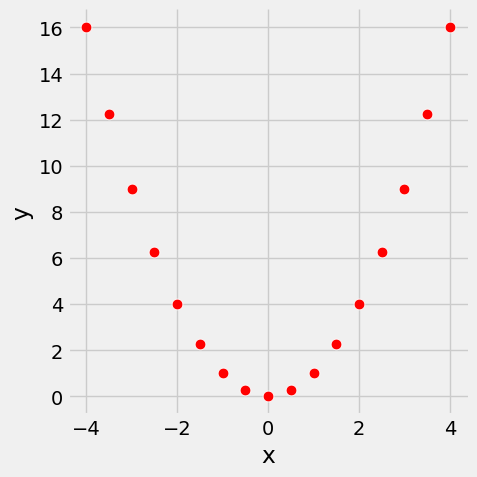

In [143]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = pd.DataFrame({'x': new_x, 'y': new_x**2})
g = sns.relplot(
    data=nonlinear,
    x='x', y='y',
    kind='scatter',
    s=60, color='r',
    height=5,
)

In [144]:
correlation(nonlinear, 'x', 'y')

np.float64(0.0)

## Correlation is Affected by Outliers
Outliers can have a big effect on correlation. Here is an example where a scatter plot for which $r$ is equal to 1 is turned into a plot for which $r$ is equal to 0, by the addition of just one outlying point.

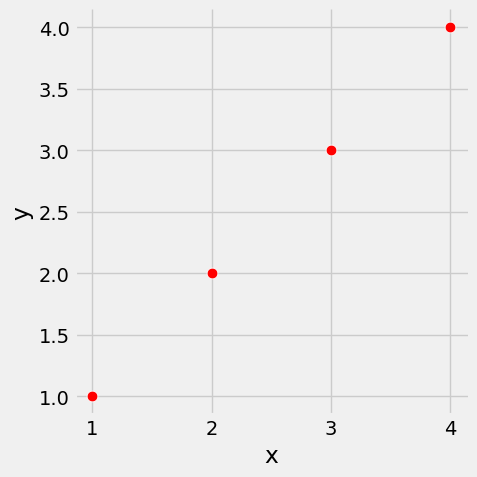

In [ ]:
line = pd.DataFrame({'x': [1, 2, 3, 4], 'y': [1, 2, 3, 4]})
g = sns.relplot(
    data=line,
    x='x', y='y',
    kind='scatter',
    height=5,
    s=60, color='r',
)

In [146]:
correlation(line, 'x', 'y')

np.float64(1.0)

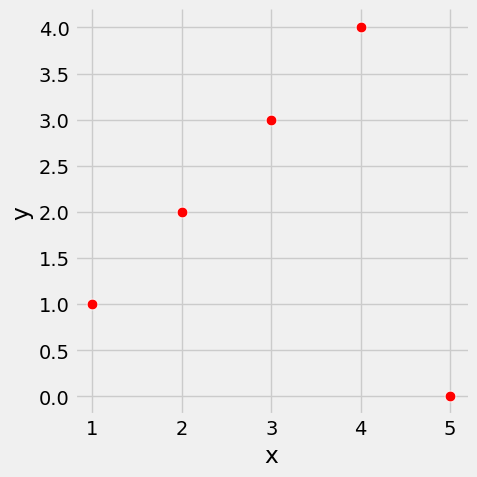

In [150]:
outlier = pd.DataFrame({'x': [1, 2, 3, 4, 5], 'y': [1, 2, 3, 4, 0]})
g = sns.relplot(
    data=outlier,
    x='x', y='y',
    kind='scatter',
    height=5,
    s=60, color='r',
)

In [151]:
correlation(outlier, 'x', 'y')

np.float64(0.0)

## Ecological Correlation

**Ecological correlation** is a correlation between two variables that are group means, in contrast to a correlation between two variables that describe individuals.

For example, one might study the correlation between physical activity and weight among sixth-grade children. A study at the individual level might make use of 100 children, then measure both physical activity and weight; the correlation between the two variables would be at the individual level.

By contrast, another study might make use of 100 classes of sixth-grade students, then measure the mean physical activity and the mean weight of each of the 100 classes. A correlation between these group means would be an example of an ecological correlation.

**Ecological fallacy**: happens when you aggregate data into groups (like classes, cities, or nations), you lose the **within-group variance**. This smoothing effect often makes correlations appear much stronger than they actually are because the "noise" of individual differences is averaged out.

### Example: Critical Reading and Math SAT scores in 2014 on 50 States

Correlations based on aggregated data can be misleading. As an example, here are data on the Critical Reading and Math SAT scores in 2014. There is one point for each of the 50 states and one for Washington, D.C. The column ``Participation Rate`` contains the percent of high school seniors who took the test. The next three columns show the average score in the state on each portion of the test, and the final column is the average of the total scores on the test.

In [153]:
sat2014 = pd.read_csv(path_data + 'sat2014.csv').sort_values('State')
sat2014.head()

,State,Participation Rate,Critical Reading,Math,Writing,Combined
21,Alabama,6.7,547,538,532,1617
34,Alaska,54.2,507,503,475,1485
26,Arizona,36.4,522,525,500,1547
15,Arkansas,4.2,573,571,554,1698
33,California,60.3,498,510,496,1504


The scatter diagram of Math scores versus Critical Reading scores is very tightly clustered around a straight line; the correlation is close to 0.985. 

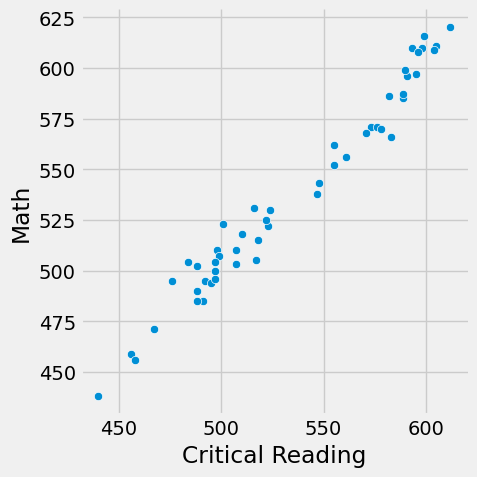

In [157]:
g = sns.relplot(
    data=sat2014,
    x='Critical Reading', y='Math',
    kind='scatter',
    height=5,
)

In [158]:
print(correlation(sat2014, 'Critical Reading', 'Math').round(3))

0.985


That's an extremely high correlation. But it's important to note that this does not reflect the strength of the relation between the Math and Critical Reading scores of *students*. 

The data consist of average scores in each state. **But states don't take tests – students do**. The data in the table have been created by lumping all the students in each state into a single point at the average values of the two variables in that state. But not all students in the state will be at that point, as students vary in their performance. If you plot a point for each student instead of just one for each state, there will be a cloud of points around each point in the figure above. The overall picture will be more fuzzy. **The correlation between the Math and Critical Reading scores of the students will be *lower* than the value calculated based on state averages**.

Correlations based on aggregates and averages are called *ecological correlations* and are frequently reported. As we have just seen, they must be interpreted with care.